In [3]:
import sympy
from sympy import symbols, Function, Eq, solve, diff, integrate, pi, simplify



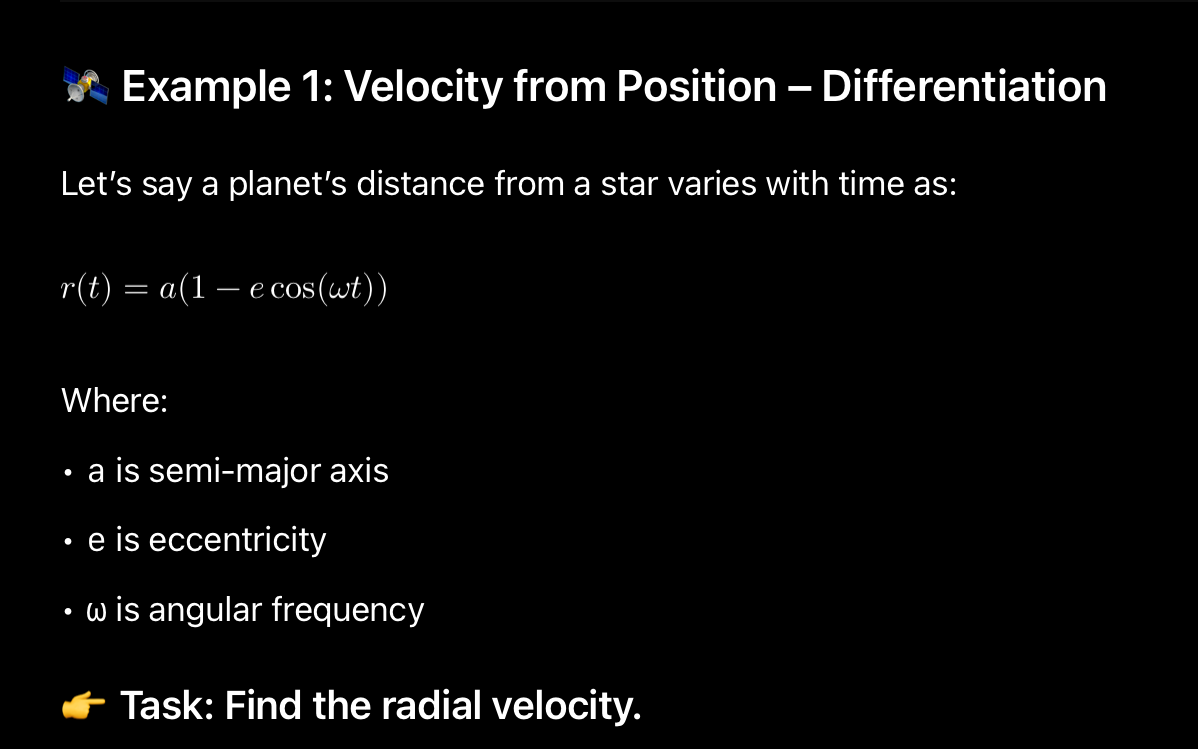

In [1]:
from sympy import symbols, cos, sin, pi, diff, simplify

# Step 1: Define symbols
t = symbols('t', real=True)                          # time in days
a = symbols('a', real=True, positive=True)           # semi-major axis in meters
e = symbols('e', real=True, positive=True)           # eccentricity
omega = symbols('omega', real=True, positive=True)   # angular frequency in rad/day

# Step 2: Define Pluto's orbital radius function
r = a * (1 - e * cos(omega * t))

# Step 3: Differentiate to get radial velocity
v_r = simplify(diff(r, t))  # This gives a*e*omega*sin(omega*t)

# Step 4: Define Pluto's orbital parameters
AU_m = 1.496e11                      # 1 AU in meters
a_pluto = 39.48 * AU_m              # semi-major axis in meters
e_pluto = 0.2488
T_pluto_days = 248 * 365.25
omega_pluto = 2 * pi / T_pluto_days
t_eval = 1000  # days

# Step 5: Substitute values
values = {
    a: a_pluto,
    e: e_pluto,
    omega: omega_pluto,
    t: t_eval
}

# Step 6: Evaluate in m/day, then convert to m/s
v_r_m_per_day = v_r.subs(values).evalf()
v_r_m_per_sec = v_r_m_per_day / (24 * 3600)

# Step 7: Output
print("Pluto radial velocity at day 1000:")
print(f"{v_r_m_per_day:.2e} m/day")
print(f"{v_r_m_per_sec:.2f} m/s")

Pluto radial velocity at day 1000:
7.06e+6 m/day
81.77 m/s


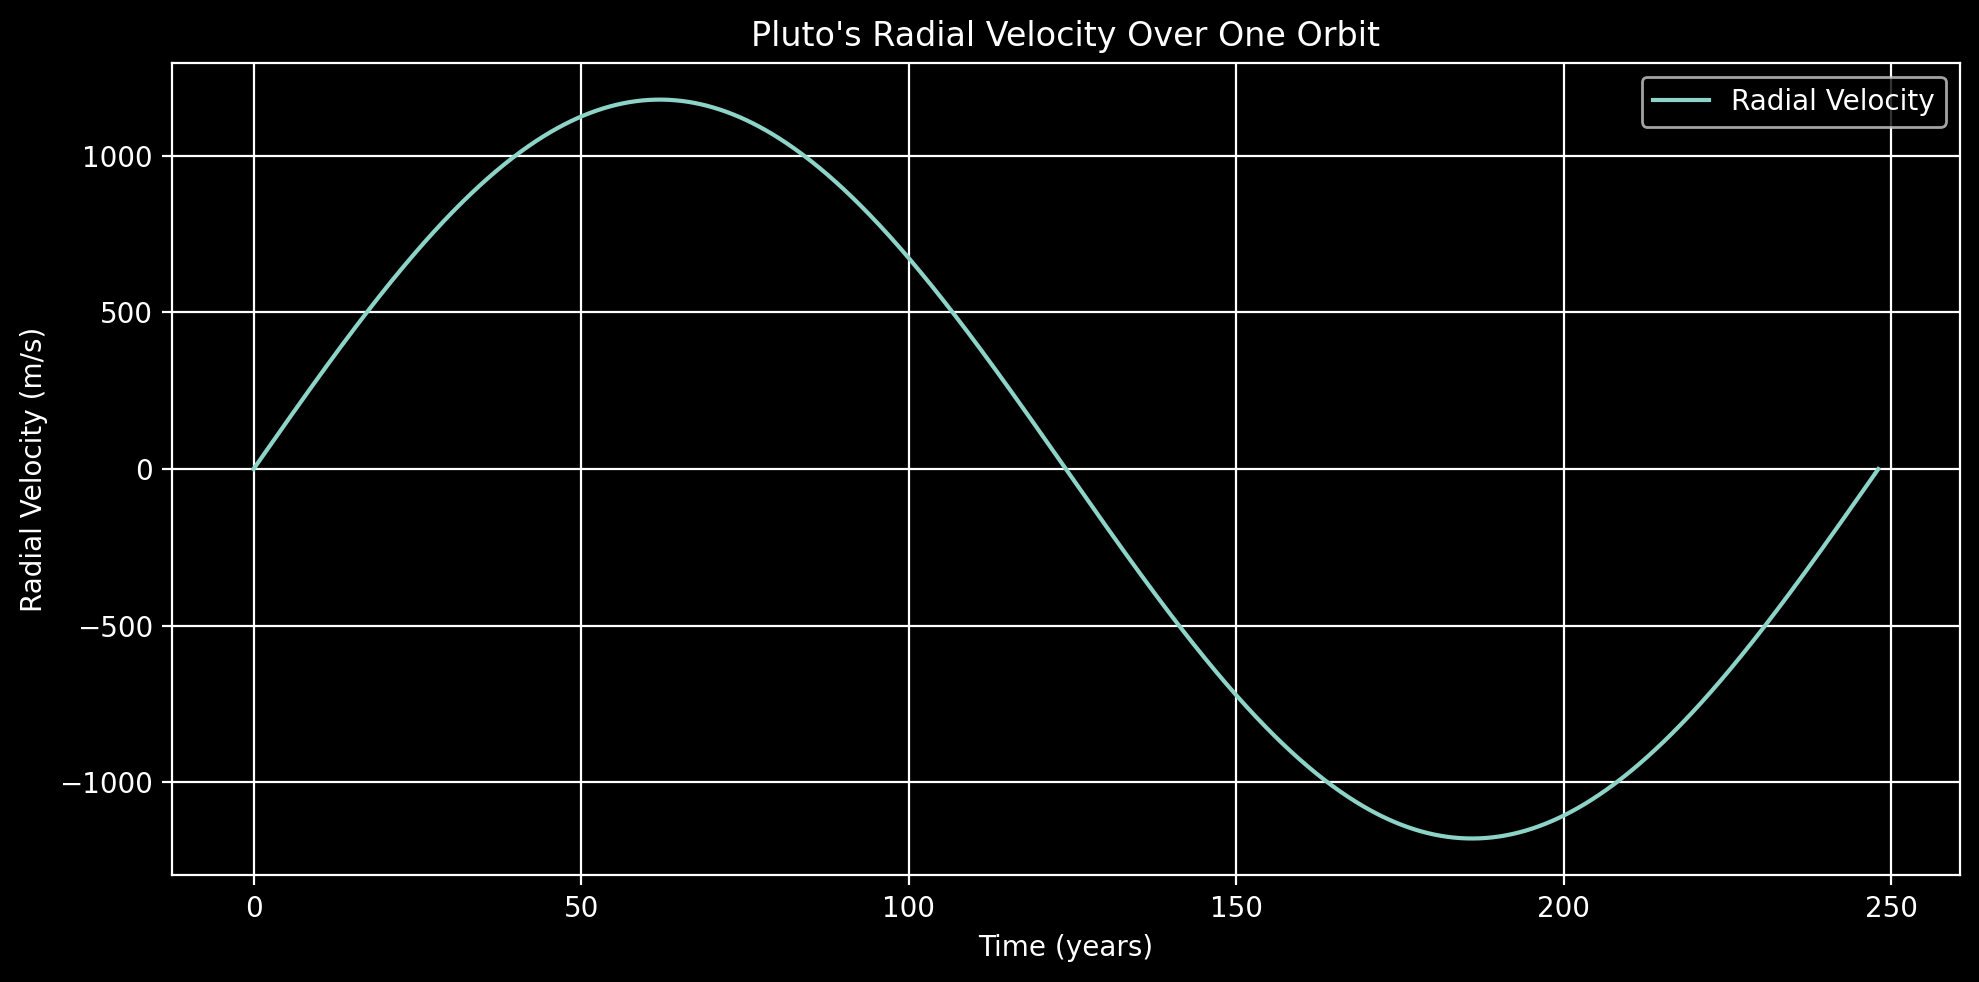

In [1]:
from sympy import symbols, cos, sin, pi, diff, simplify, lambdify
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define symbolic variables
t = symbols('t', real=True)                            # Time (days)
a = symbols('a', real=True, positive=True)             # Semi-major axis (meters)
e = symbols('e', real=True, positive=True)             # Eccentricity
omega = symbols('omega', real=True, positive=True)     # Angular frequency (rad/day)

# Step 2: Define orbital radius and differentiate to get radial velocity
r = a * (1 - e * cos(omega * t))                        # Radial distance as function of time
v_r = simplify(diff(r, t))                              # Radial velocity = dr/dt = a*e*omega*sin(omega*t)

# Step 3: Pluto’s orbital parameters
AU_meters = 1.496e11                                    # 1 AU in meters
a_pluto = 39.48 * AU_meters                             # Pluto's semi-major axis in meters
e_pluto = 0.2488                                        # Eccentricity
T_pluto_days = 248 * 365.25                             # Orbital period in days
omega_pluto = 2 * pi / T_pluto_days                     # Angular frequency in rad/day

# Step 4: Convert symbolic radial velocity to a numerical function
v_r_func = lambdify(t, v_r.subs({
    a: a_pluto,
    e: e_pluto,
    omega: omega_pluto
}), modules='numpy')

# Step 5: Generate time values (days) and evaluate radial velocity in m/s
days = np.linspace(0, T_pluto_days, 1000)               # 1000 time points over full orbit
v_r_m_per_day = v_r_func(days)                          # Evaluate radial velocity in m/day
v_r_m_per_sec = v_r_m_per_day / (24 * 3600)             # Convert to m/s

# Step 6: Plot radial velocity over time
plt.figure(figsize=(10, 5))
plt.plot(days / 365.25, v_r_m_per_sec, label="Radial Velocity")  # Time in years
plt.title("Pluto's Radial Velocity Over One Orbit")
plt.xlabel("Time (years)")
plt.ylabel("Radial Velocity (m/s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()